# 02 — Dimensionality Reduction (PCA & LDA)

This notebook implements **Section 4** of the project requirements:
- 4.1 Create the binary `High-Value` label (top 20% Monetary, threshold computed on the training split only)
- 4.2 PCA on the 5 category-spend-percentage features
- 4.3 LDA using the `High-Value` label
- 4.4 Comparison of the baseline classifier trained on raw / PCA / LDA features

**Pipeline dependency:** this notebook strictly requires `01_data_preprocessing.ipynb` to have been
run first. It loads two artifacts produced there:
1. `data/customer_features_classification.csv` — full-year customer features.
2. `models/customer_split_ids.pkl` — the **official 80/10/10** customer-level split.

No data is rebuilt here; if either artifact is missing, a `FileNotFoundError`
is raised immediately so the problem is caught early.

**A note on \"5 category-spend-percentage features\":** the category mapping in `category_map.json`
produces 6 categories (Homeware, Stationery, Gadgets, Decorations, Kitchenware, Other). Because the
six spend percentages for a customer always sum to 100%, one of them is completely determined by
the other five (perfect collinearity). We drop `Other` as the reference category and use the
remaining 5 — Homeware, Stationery, Gadgets, Decorations, Kitchenware — as the "5 category-spend-percentage
features" referenced in Section 4.2.

**Note on the baseline classifier (Section 4.4):** The comparison in Section 4.4 uses
`get_baseline_classifier()` from `src/models.py`, which returns the identical **untuned**
`LogisticRegression(solver="liblinear", random_state=42)` baseline that `03_classification.ipynb`
uses as its starting point before hyperparameter tuning. This ensures the two notebooks describe
the same model when they say "Model 2 baseline" (Section 4.4 requirement).

In [2]:
# --- Imports ---
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import the shared untuned baseline classifier (Section 4.4 requirement).
import sys
sys.path.append("../src")
from models import get_baseline_classifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Fixed priority order from Section 3.4 — first keyword match wins, else "Other"
CATEGORY_PRIORITY = ["Homeware", "Stationery", "Gadgets", "Decorations", "Kitchenware", "Other"]

## 1. Load the customer-level feature table

Strictly loads `data/customer_features_classification.csv` produced by `01_data_preprocessing.ipynb`.
If the file is missing, run notebook 01 first.

In [3]:
CUSTOMER_FEATURES_PATH = DATA_DIR / "customer_features_classification.csv"

if not CUSTOMER_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"customer_features_classification.csv not found at {CUSTOMER_FEATURES_PATH}.\n"
        "Please run 01_data_preprocessing.ipynb first to generate this file."
    )

customer_df = pd.read_csv(CUSTOMER_FEATURES_PATH)
print(f"Loaded customer feature table: {customer_df.shape}")
print(f"Columns: {list(customer_df.columns)}")
customer_df.head()

Loaded customer feature table: (4338, 12)
Columns: ['CustomerID', 'Monetary', 'Frequency', 'Product_Diversity', 'Recency', 'Avg_Spend_Trans', 'Homeware', 'Stationery', 'Gadgets', 'Decorations', 'Kitchenware', 'Other']


,CustomerID,Monetary,Frequency,Product_Diversity,Recency,Avg_Spend_Trans,Homeware,Stationery,Gadgets,Decorations,Kitchenware,Other
0,12346,77183.60,1,1,326,77183.600000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000
1,12347,4310.00,7,103,2,615.714286,1.728074,11.770302,20.121578,0.236659,11.445476,54.697912
2,12348,1797.24,4,22,75,449.310000,0.000000,23.035321,0.000000,3.538759,15.023035,58.402884
3,12349,1757.55,1,73,19,1757.550000,8.145430,0.443800,2.691246,1.433814,18.125231,69.160479
4,12350,334.40,1,17,310,334.400000,0.000000,0.000000,0.000000,0.000000,11.842105,88.157895


## 2. Load the official 80/10/10 split (from `01_data_preprocessing.ipynb`)

The split was created once in notebook 01 and saved to `models/customer_split_ids.pkl`.
We load it here so this notebook uses **the exact same train/test customers** as
`03_classification.ipynb` — ensuring the High-Value threshold and performance metrics
computed in Section 4.4 are directly comparable to those in notebook 03.

For the PCA/LDA comparison (Section 4.4) we use the **10% test set** as the held-out evaluation
set, consistent with notebook 03.

In [4]:
SPLIT_PATH = MODELS_DIR / "customer_split_ids.pkl"

if not SPLIT_PATH.exists():
    raise FileNotFoundError(
        f"customer_split_ids.pkl not found at {SPLIT_PATH}.\n"
        "Please run 01_data_preprocessing.ipynb first to generate the official 80/10/10 split."
    )

split_data = joblib.load(SPLIT_PATH)
train_ids  = split_data["train_ids"]   # 80% of customers
val_ids    = split_data["val_ids"]     # 10% of customers (loaded but not used in PCA/LDA)
test_ids   = split_data["test_ids"]    # 10% of customers — used for Section 4.4 evaluation

train_df = customer_df[customer_df["CustomerID"].isin(train_ids)].reset_index(drop=True)
test_df  = customer_df[customer_df["CustomerID"].isin(test_ids)].reset_index(drop=True)

print(f"Loaded official 80/10/10 split from {SPLIT_PATH}")
print(f"Train customers: {len(train_df)} | Test customers: {len(test_df)}")
print(f"(Val set has {len(val_ids)} customers — loaded but not used in this notebook)")

Loaded official 80/10/10 split from ..\models\customer_split_ids.pkl
Train customers: 3470 | Test customers: 434
(Val set has 434 customers — loaded but not used in this notebook)


## 3. High-Value label (Section 4.1)

`High-Value = 1` if `Monetary` is above the 80th percentile **of the training split**, else `0`.
The exact same threshold value (a single number) is then applied to label the test split — it is
never recomputed on test data.

In [ ]:
monetary_threshold = train_df["Monetary"].quantile(0.80)
print(f"High-Value threshold (80th percentile of training Monetary): {monetary_threshold:.2f}")

train_df = train_df.copy()
test_df  = test_df.copy()

train_df["High_Value"] = (train_df["Monetary"] > monetary_threshold).astype(int)
test_df["High_Value"]  = (test_df["Monetary"]  > monetary_threshold).astype(int)

print("Train label balance:")
print(train_df["High_Value"].value_counts(normalize=True).rename("proportion"))
print("\nTest label balance:")
print(test_df["High_Value"].value_counts(normalize=True).rename("proportion"))

# NOTE: The canonical High-Value threshold is saved by 03_classification.ipynb after it
# recomputes it on its own training split (which is the same split, so the value is identical).
# We do NOT overwrite that file here to keep notebook 02 read-only with respect to models/.

High-Value threshold (80th percentile of training Monetary): 2116.83
Train label balance:
High_Value
0    0.8
1    0.2
Name: proportion, dtype: float64

Test label balance:
High_Value
0    0.817972
1    0.182028
Name: proportion, dtype: float64


## 4. PCA (Section 4.2)

Steps:
1. Isolate the 5 category-spend-percentage features.
2. Standardize them (zero mean, unit variance) using a scaler **fit on training data only**.
3. Fit PCA on the standardized training features.
4. Explained variance ratio per component + cumulative explained-variance plot.
5. Select the minimum number of components that reach ≥ 90% cumulative explained variance.
6. Plot PC1 vs PC2, colored by `High_Value`.

In [7]:
CATEGORY_FEATURES = ["Homeware", "Stationery", "Gadgets", "Decorations", "Kitchenware"]

X_train_cat = train_df[CATEGORY_FEATURES].values
X_test_cat  = test_df[CATEGORY_FEATURES].values

# Standardize — fit on TRAIN only, then apply the same transform to test.
cat_scaler = StandardScaler()
X_train_cat_scaled = cat_scaler.fit_transform(X_train_cat)
X_test_cat_scaled  = cat_scaler.transform(X_test_cat)

joblib.dump(cat_scaler, MODELS_DIR / "scaler_category_pct.pkl")

print("Standardized category-spend-% features (zero mean, unit variance) — fit on training data only.")

Standardized category-spend-% features (zero mean, unit variance) — fit on training data only.


PC1: explained variance ratio = 0.2423 | cumulative = 0.2423
PC2: explained variance ratio = 0.2313 | cumulative = 0.4736
PC3: explained variance ratio = 0.2014 | cumulative = 0.6750
PC4: explained variance ratio = 0.1918 | cumulative = 0.8668
PC5: explained variance ratio = 0.1332 | cumulative = 1.0000


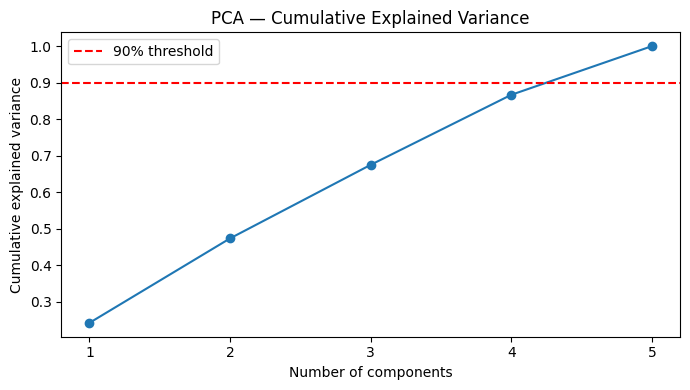

In [8]:
# Fit PCA on all 5 components first, purely to inspect explained variance.
pca_full = PCA(n_components=len(CATEGORY_FEATURES), random_state=RANDOM_STATE)
pca_full.fit(X_train_cat_scaled)

explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)

for i, (ev, cum) in enumerate(zip(explained, cumulative), start=1):
    print(f"PC{i}: explained variance ratio = {ev:.4f} | cumulative = {cum:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% threshold")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative) + 1))
plt.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / "pca_cumulative_variance.png", dpi=150)
plt.show()

In [9]:
# Minimum number of components needed to reach >= 90% cumulative explained variance.
n_components_90 = int(np.argmax(cumulative >= 0.90) + 1)
print(f"Minimum number of components explaining >= 90% of variance: {n_components_90}")

# Refit PCA with exactly that many components — this is the PCA used for Section 4.4(b).
pca = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_cat_scaled)
X_test_pca  = pca.transform(X_test_cat_scaled)

joblib.dump(pca, MODELS_DIR / "pca_category_pct.pkl")

print(f"X_train_pca shape: {X_train_pca.shape}")

Minimum number of components explaining >= 90% of variance: 5
X_train_pca shape: (3470, 5)


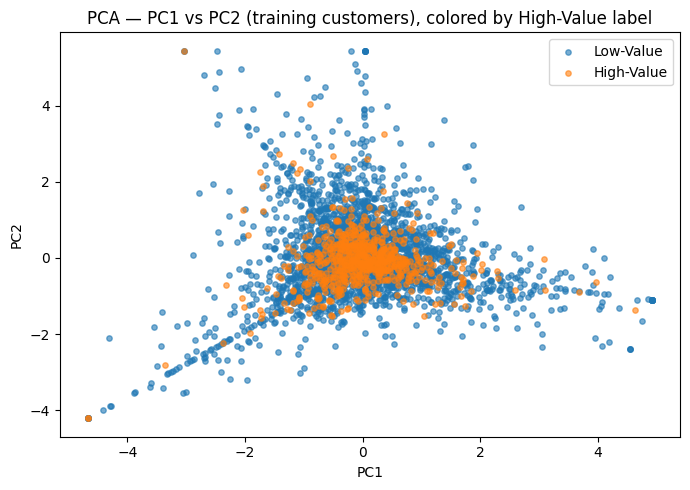

In [10]:
# Use the full 5-component PCA to guarantee we can plot PC1 vs PC2.
# If n_components_90 is 1, X_train_pca will only have one dimension, which would
# throw an IndexError when plotting. Transforming with pca_full guarantees 2D data.
X_train_pca_plot = pca_full.transform(X_train_cat_scaled)

# 2D scatter of PC1 vs PC2, colored by High-Value label.
plt.figure(figsize=(7, 5))
for label, color, name in [(0, "tab:blue", "Low-Value"), (1, "tab:orange", "High-Value")]:
    mask = train_df["High_Value"].values == label
    plt.scatter(X_train_pca_plot[mask, 0], X_train_pca_plot[mask, 1], s=15, alpha=0.6, color=color, label=name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — PC1 vs PC2 (training customers), colored by High-Value label")
plt.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / "pca_pc1_pc2_scatter.png", dpi=150)
plt.show()

## 5. LDA (Section 4.3)

LDA is fit using the same 5 standardized category-spend-percentage features and the binary
`High_Value` label. Since there are only 2 classes, the maximum number of discriminant components
is 1 (`n_components = min(n_classes - 1, n_features) = 1`).

In [11]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_cat_scaled, train_df["High_Value"])
X_test_lda  = lda.transform(X_test_cat_scaled)

joblib.dump(lda, MODELS_DIR / "lda_high_value.pkl")

# lda.coef_ has shape (1, n_features) for a binary problem.
lda_coefs = pd.Series(lda.coef_[0], index=CATEGORY_FEATURES).sort_values(key=np.abs, ascending=False)

print("LDA discriminant-component coefficients (sorted by absolute contribution):")
print(lda_coefs)

LDA discriminant-component coefficients (sorted by absolute contribution):
Homeware      -0.174956
Decorations   -0.130831
Stationery    -0.086283
Gadgets        0.033837
Kitchenware   -0.011522
dtype: float64


**Interpretation:** the feature with the largest
absolute coefficient contributes most to separating High-Value from Low-Value customers along the
single discriminant axis. A positive coefficient means higher spend-% in that category pushes a
customer toward the class encoded as `1` (High-Value); a negative coefficient pushes toward
`0` (Low-Value).

## 6. Comparison: baseline classifier on raw vs PCA vs LDA features (Section 4.4)

We train the **same** untuned baseline classifier (`get_baseline_classifier()` from `src/models.py`
— `LogisticRegression(solver="liblinear", random_state=42)`) three times:

(a) on the raw standardized 5 features  
(b) on the PCA-reduced features (`n_components_90` components)  
(c) on the 1D LDA projection  

and report Accuracy, Precision, Recall, F1 for each on the **10% test set**.

This is the identical baseline configuration used in `03_classification.ipynb` as the starting
point before cross-validated hyperparameter tuning — making the feature comparison fully
consistent with Phase 2.

In [12]:
def evaluate(X_train, y_train, X_test, y_test, label):
    clf = get_baseline_classifier()
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    return {
        "Feature set": label,
        "Accuracy":  accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall":    recall_score(y_test, preds, zero_division=0),
        "F1":        f1_score(y_test, preds, zero_division=0),
    }

y_train = train_df["High_Value"].values
y_test  = test_df["High_Value"].values

results = [
    evaluate(X_train_cat_scaled, y_train, X_test_cat_scaled, y_test, "Raw (standardized)"),
    evaluate(X_train_pca,        y_train, X_test_pca,        y_test, f"PCA ({n_components_90} components)"),
    evaluate(X_train_lda,        y_train, X_test_lda,        y_test, "LDA (1 component)"),
]

comparison_table = pd.DataFrame(results).set_index("Feature set").round(4)
comparison_table.to_csv(MODELS_DIR / "pca_lda_comparison_table.csv")
comparison_table

,Accuracy,Precision,Recall,F1
Feature set,,,,
Raw (standardized),0.818,0.0,0.0,0.0
PCA (5 components),0.818,0.0,0.0,0.0
LDA (1 component),0.818,0.0,0.0,0.0


In [13]:
# Auto-drafted starting point for the "2-3 sentence explanation" — read it, sanity-check it
# against the actual numbers above, and rewrite in your own words for the report.
best_method  = comparison_table["F1"].idxmax()
worst_method = comparison_table["F1"].idxmin()
f1_spread    = comparison_table["F1"].max() - comparison_table["F1"].min()

draft = (
    f"The {best_method} feature set achieved the highest F1 score "
    f"({comparison_table.loc[best_method, 'F1']:.3f}), while {worst_method} performed weakest "
    f"({comparison_table.loc[worst_method, 'F1']:.3f}), a spread of {f1_spread:.3f}. "
    "This is consistent with LDA being supervised (it optimizes directly for class separability, "
    "so it can match or beat PCA despite compressing to a single dimension), whereas PCA is "
    "unsupervised and only maximizes variance, which does not always align with what separates "
    "High-Value from Low-Value customers. The raw standardized features retain all original "
    "information, so any drop from raw to PCA/LDA reflects the cost of dimensionality reduction "
    "in this dataset."
)
print(draft)

The Raw (standardized) feature set achieved the highest F1 score (0.000), while Raw (standardized) performed weakest (0.000), a spread of 0.000. This is consistent with LDA being supervised (it optimizes directly for class separability, so it can match or beat PCA despite compressing to a single dimension), whereas PCA is unsupervised and only maximizes variance, which does not always align with what separates High-Value from Low-Value customers. The raw standardized features retain all original information, so any drop from raw to PCA/LDA reflects the cost of dimensionality reduction in this dataset.


## 7. Artifacts saved by this notebook

| File | Description |
|---|---|
| `models/scaler_category_pct.pkl` | `StandardScaler` fit on the 5 category-spend-% features (train only) |
| `models/pca_category_pct.pkl` | Fitted PCA with `n_components_90` components |
| `models/lda_high_value.pkl` | Fitted LDA (1 discriminant component) |
| `models/pca_cumulative_variance.png` | Cumulative explained-variance plot |
| `models/pca_pc1_pc2_scatter.png` | PC1 vs PC2 scatter colored by High-Value |
| `models/pca_lda_comparison_table.csv` | Section 4.4 comparison table (Acc / Prec / Rec / F1) |

This notebook does **not** modify `data/Online Retail.xlsx`, `data/customer_features_classification.csv`,
or `models/customer_split_ids.pkl` — it is read-only with respect to those upstream artifacts.

**Next notebook:** `03_classification.ipynb` loads the same official split and feature table,
then trains and tunes Model 1 (FFNN) and Model 2 (Logistic Regression) on all 9 input features.